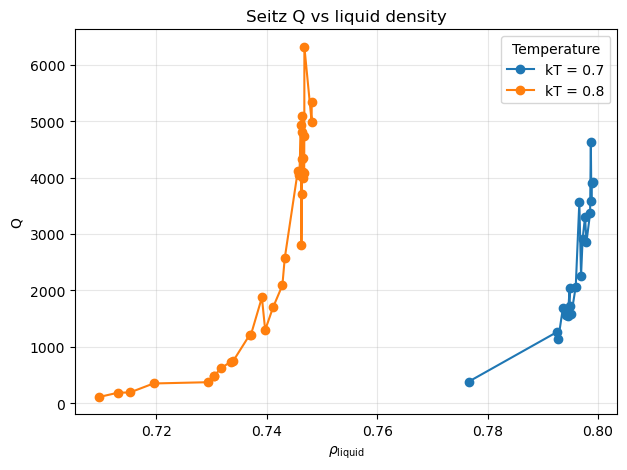

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from md_Helpers import paths

seitz_path = paths.MASTER_CSVS_V3_ROOT / "seitz_master.csv"
seitz = pd.read_csv(seitz_path)

plot_data = (
    seitz[
        (seitz["status"] == "seitz_computed")
        & seitz["Q"].notna()
        & seitz["rho_liquid"].notna()
        & seitz["source_kT"].notna()
    ]
    .sort_values(["source_kT", "rho_liquid"])
)

fig, ax = plt.subplots(figsize=(7, 5))

for kT, group in plot_data.groupby("source_kT"):
    ax.plot(
        group["rho_liquid"],
        group["Q"],
        marker="o",
        linewidth=1.5,
        label=f"kT = {kT:g}",
    )

ax.set_xlabel(r"$\rho_\mathrm{liquid}$")
ax.set_ylabel("Q")
ax.set_title("Seitz Q vs liquid density")
ax.legend(title="Temperature")
ax.grid(True, alpha=0.3)

plt.show()